# Analyse globale — Incremental / Online_newjob / Hybrid-n_j

Quatre angles, pour chaque phase (A: palier/échelle, B: n_existing, C: aléatoire) :

1. **Compromis flow time** — le nouveau job gagne-t-il au prix du reste du batch, ou pas ?
2. **Temps de scheduling** (mur)
3. **Coût de placement** — énergie de transfert liée aux transferts effectués
4. **Synthèse** — une vue d'ensemble sur les 16 scénarios

Données : `results-validation-2026-10-07/phaseABC_full_metrics.csv` (protocole figé,
single-decision-point, Mac local).

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("results-validation-2026-10-07/phaseABC_full_metrics.csv")
df = df[df.no_solution != True].copy()

APPROACH_DISPLAY = {"incremental": "Incremental", "online_newjob": "Online_newjob", "hybrid": "Hybrid-n_j"}
df["approach_disp"] = df["approach"].map(APPROACH_DISPLAY)
colors = {"Incremental": "#8C8C8C", "Online_newjob": "#4472C4", "Hybrid-n_j": "#2E8B57"}
markers = {"Incremental": "o", "Online_newjob": "^", "Hybrid-n_j": "D"}
order = ["Incremental", "Online_newjob", "Hybrid-n_j"]

PHASE_LABEL = {"A": "Phase A — palier / échelle", "B": "Phase B — n_existing", "C": "Phase C — aléatoire"}
df["phase_label"] = df["phase"].map(PHASE_LABEL)
df["scenario"] = df.apply(lambda r: f"{r.group}:{r.tag}" if r.phase == "A" else r.tag, axis=1)

print(f"{len(df)} lignes, {df.scenario.nunique()} scénarios distincts")
df.head()

48 lignes, 16 scénarios distincts


,phase,group,tag,n_existing,nb_nodes,new_job_dataset_size,new_job_nb_tasks,new_job_task_duration,dataset_size_range_lo,dataset_size_range_hi,...,data_transferred_new_job_mb,storage_violations,hybrid_f1,hybrid_escalation_budget,hybrid_accepted,hybrid_winning_variant,no_solution,approach_disp,phase_label,scenario
0,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,NaN,NaN,NaN,NaN,False,Incremental,Phase A — palier / échelle,palier:petit
1,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,NaN,NaN,NaN,NaN,False,Online_newjob,Phase A — palier / échelle,palier:petit
2,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,2106.0,NaN,False,freeze_below_mean,False,Hybrid-n_j,Phase A — palier / échelle,palier:petit
3,A,palier,grand,5,50,389472,19,594,204800,409600,...,2726304,0,NaN,NaN,NaN,NaN,False,Incremental,Phase A — palier / échelle,palier:grand
4,A,palier,grand,5,50,389472,19,594,204800,409600,...,3115776,0,NaN,NaN,NaN,NaN,False,Online_newjob,Phase A — palier / échelle,palier:grand


## Fonctions de graphique

- `tradeoff_scatter` : un point par (scénario, approche) -- abscisse = impact moyen sur le
  **reste** du batch (`mean_flow_time_all`, recalculé en excluant le nouveau job pour ne pas se
  mordre la queue), ordonnée = flow time du **nouveau job**. En bas à gauche = gagnant sur les
  deux fronts. Les flèches relient Incremental à Hybrid pour le même scénario, pour voir le
  déplacement.
- `sorted_hbar` : barres horizontales triées par valeur, une ligne par (scénario, approche),
  regroupées visuellement par scénario.

In [2]:
# mean_flow_time_all inclut le nouveau job -- on retire sa propre contribution pour isoler
# l'impact sur le RESTE du batch uniquement (sinon un nouveau job très rapide gonflerait
# artificiellement l'air de "tout va bien" du côté x).
def others_mean_flow(row):
    n = row.batch_size
    if n <= 1 or pd.isna(row.mean_flow_time_all):
        return row.mean_flow_time_all
    total = row.mean_flow_time_all * n
    others_total = total - row.flow_time_new_job
    return others_total / (n - 1)

df["mean_flow_time_others"] = df.apply(others_mean_flow, axis=1)


def tradeoff_scatter(ax, sub, title):
    for appr in order:
        s = sub[sub.approach_disp == appr]
        ax.scatter(s.mean_flow_time_others, s.flow_time_new_job, label=appr, color=colors[appr],
                   marker=markers[appr], s=90, edgecolor="white", linewidth=0.8, zorder=3)
    # Fleche Incremental -> Hybrid, meme scenario
    for scenario in sub.scenario.unique():
        row_inc = sub[(sub.scenario == scenario) & (sub.approach_disp == "Incremental")]
        row_hyb = sub[(sub.scenario == scenario) & (sub.approach_disp == "Hybrid-n_j")]
        if len(row_inc) and len(row_hyb):
            x0, y0 = row_inc.mean_flow_time_others.iloc[0], row_inc.flow_time_new_job.iloc[0]
            x1, y1 = row_hyb.mean_flow_time_others.iloc[0], row_hyb.flow_time_new_job.iloc[0]
            if (x0, y0) != (x1, y1):
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                            arrowprops=dict(arrowstyle="->", color="#BBBBBB", lw=1.1, shrinkA=6, shrinkB=6), zorder=1)
    ax.set_xlabel("flow time moyen -- RESTE du batch")
    ax.set_ylabel("flow time -- nouveau job")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")


def sorted_hbar(ax, sub, value_col, title, xlabel):
    sub2 = sub.copy()
    sub2["label"] = sub2.scenario + " · " + sub2.approach_disp
    sub2 = sub2.sort_values(value_col)
    colors_list = [colors[a] for a in sub2.approach_disp]
    ax.barh(sub2.label, sub2[value_col], color=colors_list, height=0.7)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)
    handles = [mpatches.Patch(color=colors[a], label=a) for a in order]
    ax.legend(handles=handles, fontsize=7, loc="lower right")

## Phase A — palier / échelle

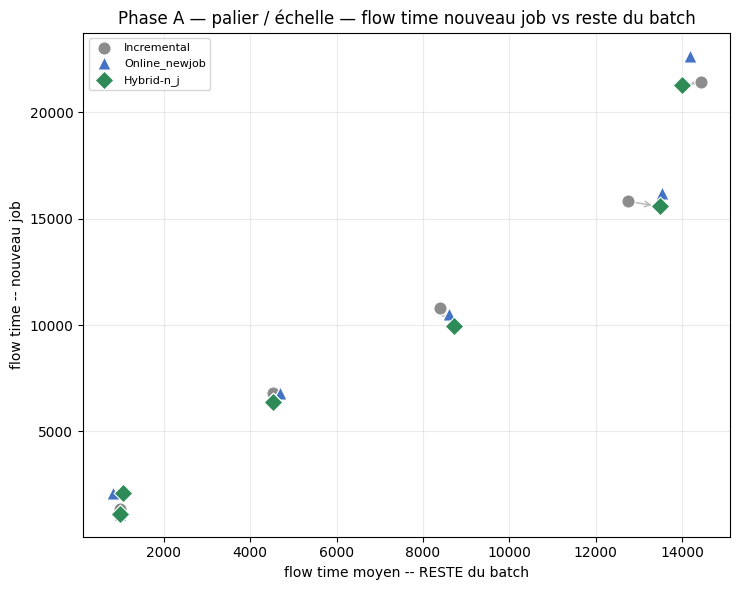

In [3]:
sub = df[df.phase == "A"]

fig, ax = plt.subplots(figsize=(7.5, 6))
tradeoff_scatter(ax, sub, "Phase A — palier / échelle — flow time nouveau job vs reste du batch")
plt.tight_layout()
plt.show()

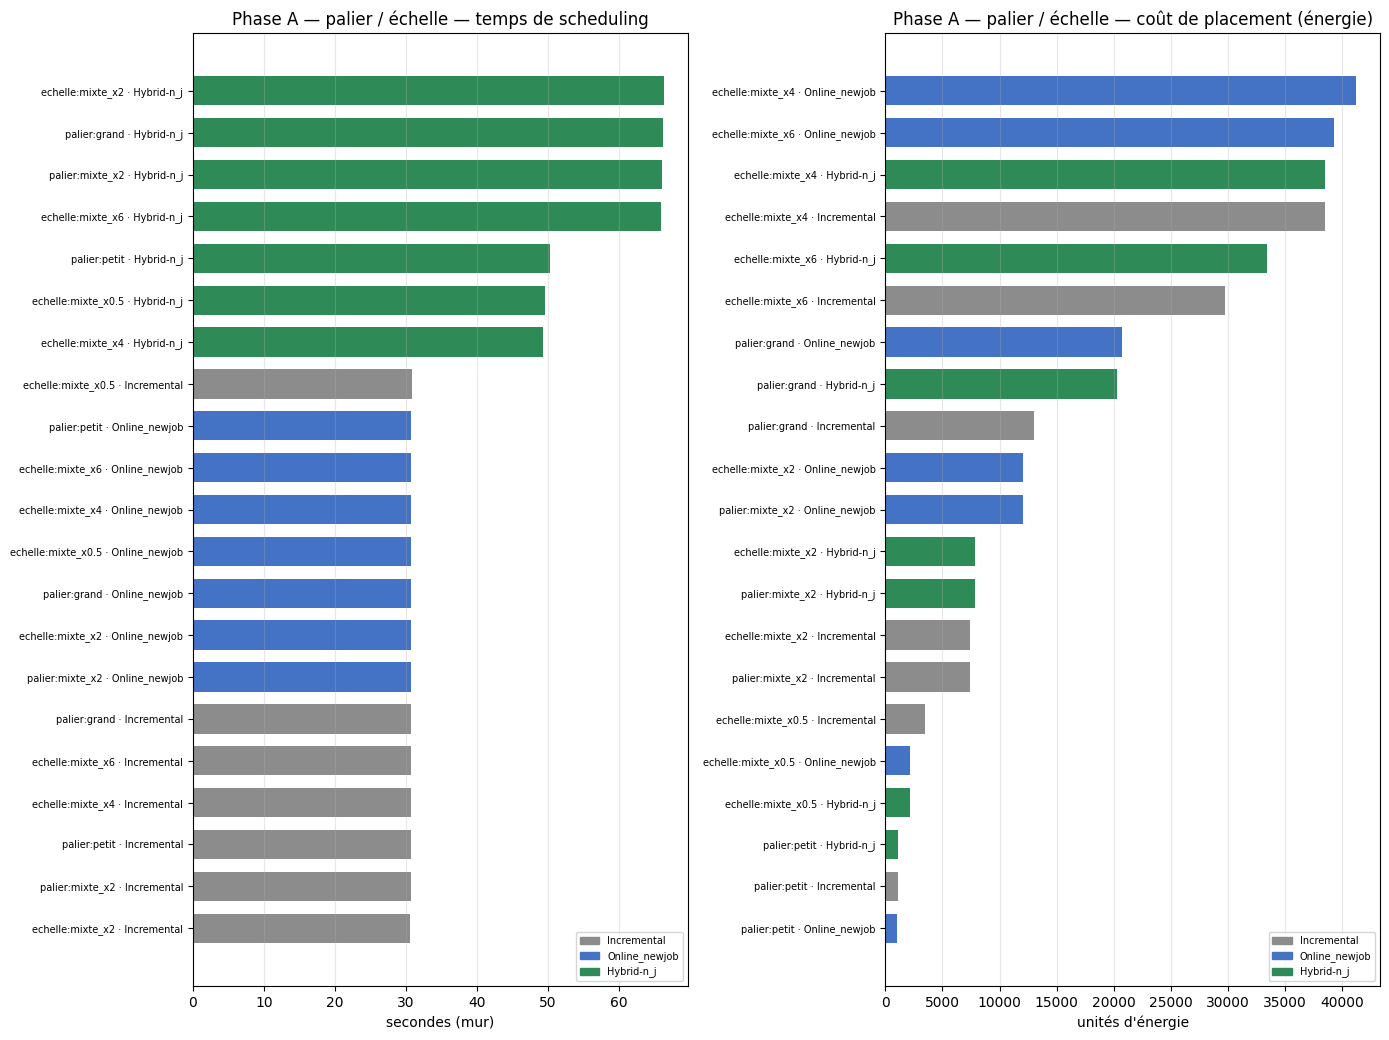

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.5 * sub.scenario.nunique() * 3)))
sorted_hbar(axes[0], sub, "scheduling_time_s", "Phase A — palier / échelle — temps de scheduling", "secondes (mur)")
sorted_hbar(axes[1], sub, "transfer_energy_total", "Phase A — palier / échelle — coût de placement (énergie)", "unités d'énergie")
plt.tight_layout()
plt.show()

## Phase B — n_existing

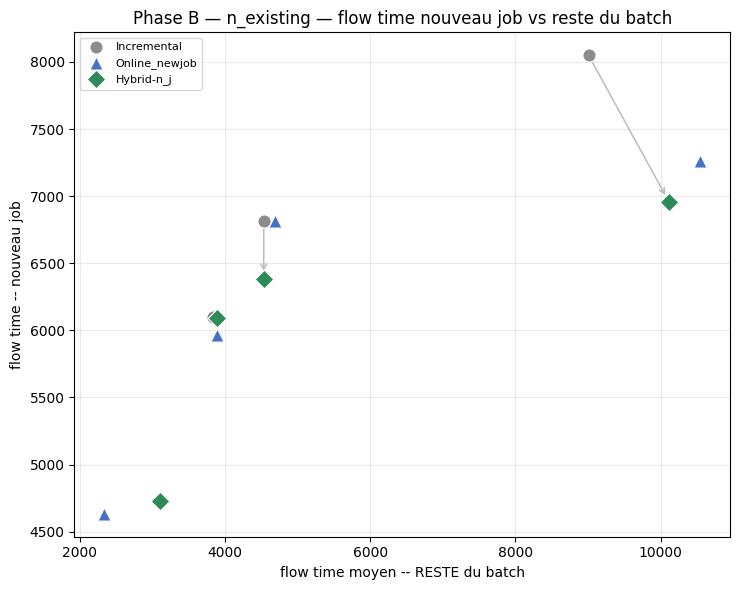

In [5]:
sub = df[df.phase == "B"]

fig, ax = plt.subplots(figsize=(7.5, 6))
tradeoff_scatter(ax, sub, "Phase B — n_existing — flow time nouveau job vs reste du batch")
plt.tight_layout()
plt.show()

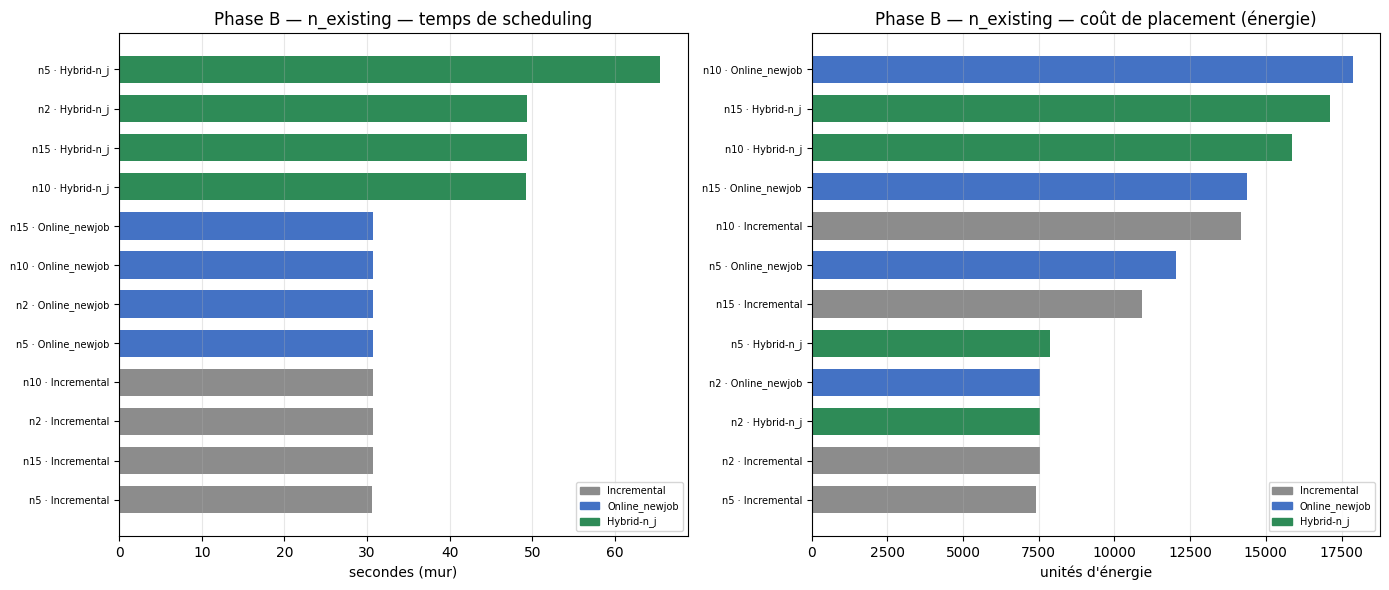

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.5 * sub.scenario.nunique() * 3)))
sorted_hbar(axes[0], sub, "scheduling_time_s", "Phase B — n_existing — temps de scheduling", "secondes (mur)")
sorted_hbar(axes[1], sub, "transfer_energy_total", "Phase B — n_existing — coût de placement (énergie)", "unités d'énergie")
plt.tight_layout()
plt.show()

## Phase C — aléatoire

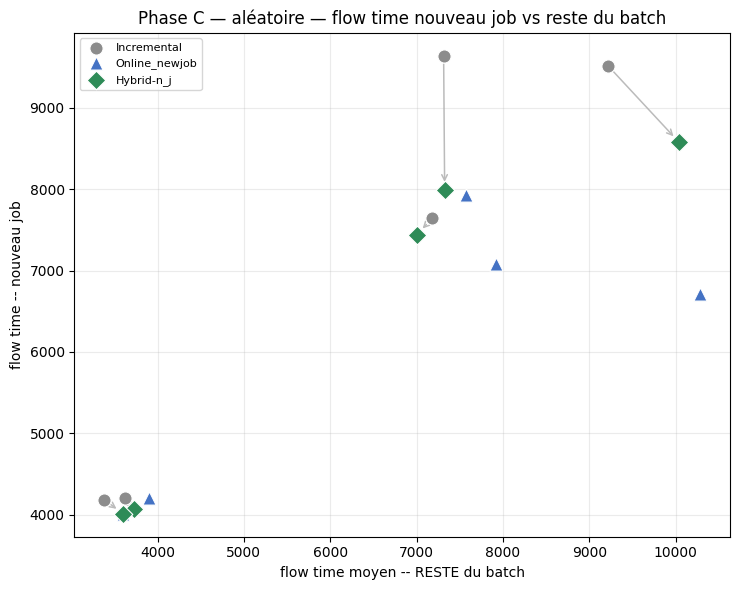

In [7]:
sub = df[df.phase == "C"]

fig, ax = plt.subplots(figsize=(7.5, 6))
tradeoff_scatter(ax, sub, "Phase C — aléatoire — flow time nouveau job vs reste du batch")
plt.tight_layout()
plt.show()

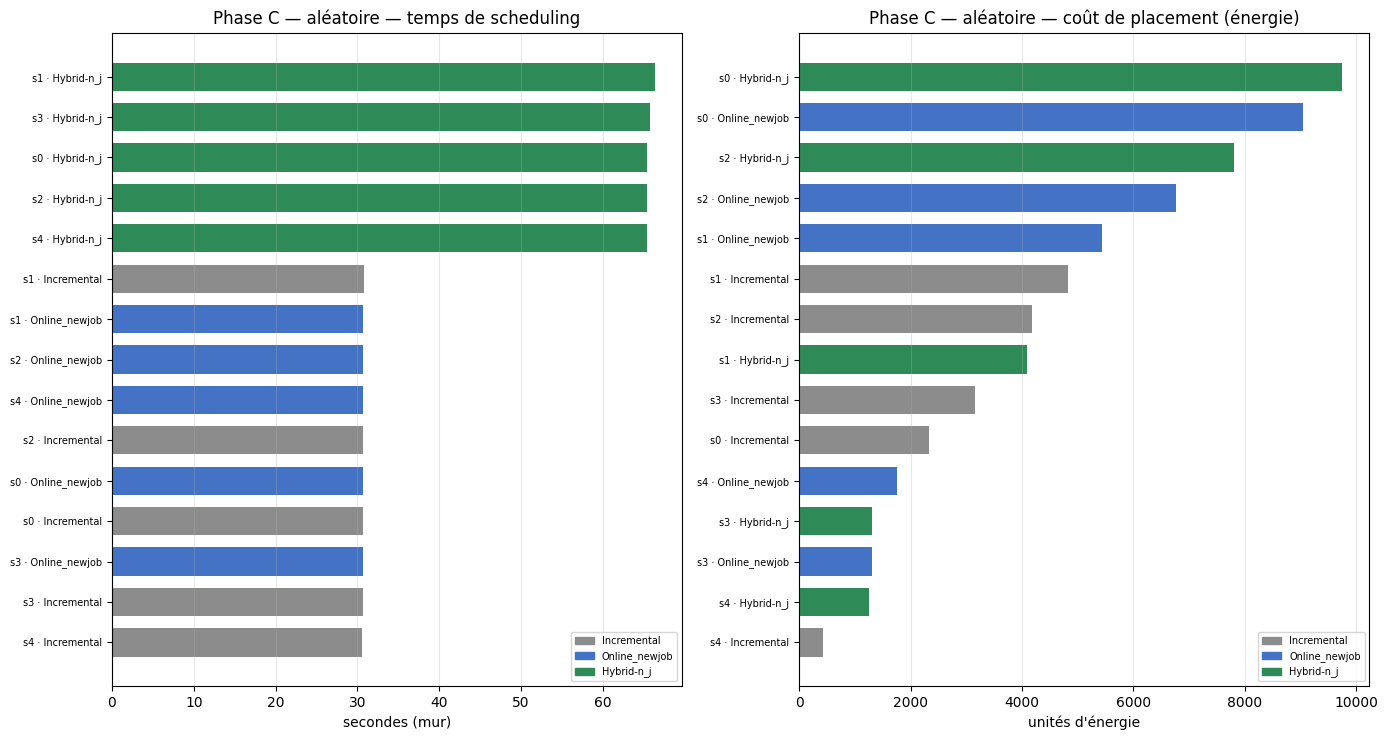

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.5 * sub.scenario.nunique() * 3)))
sorted_hbar(axes[0], sub, "scheduling_time_s", "Phase C — aléatoire — temps de scheduling", "secondes (mur)")
sorted_hbar(axes[1], sub, "transfer_energy_total", "Phase C — aléatoire — coût de placement (énergie)", "unités d'énergie")
plt.tight_layout()
plt.show()

## Synthèse — les 16 scénarios ensemble

Même nuage de points que par phase, mais toutes les phases superposées (marqueur = approche,
couleur de fond = phase) pour voir si une phase se comporte différemment des autres.

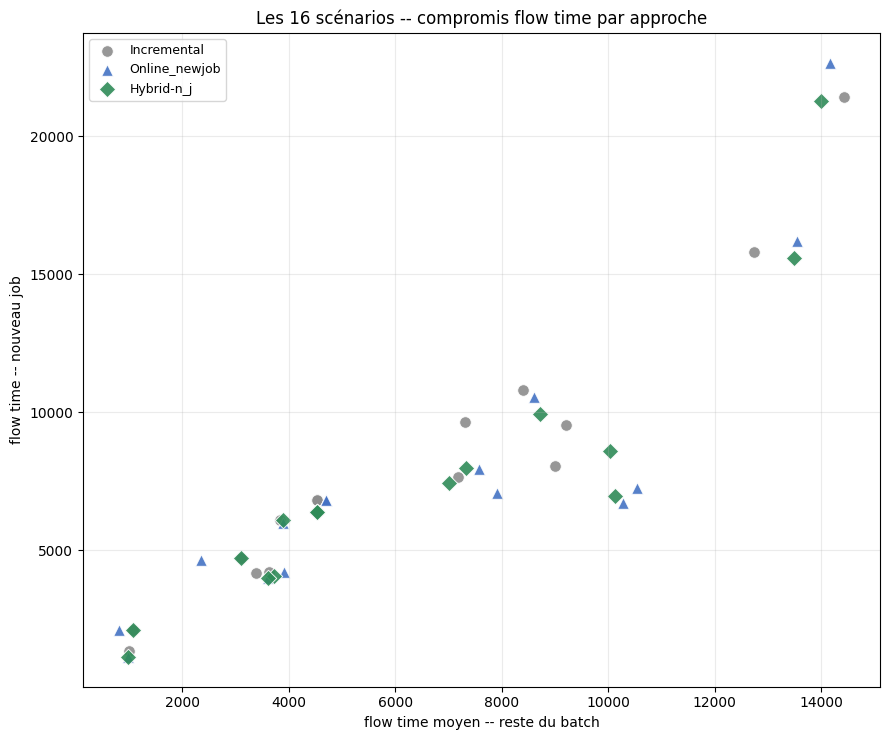

In [9]:
phase_bg = {"A": "#FDECEC", "B": "#EAF2FB", "C": "#EAF7EC"}
fig, ax = plt.subplots(figsize=(9, 7.5))
for phase_key in ["A", "B", "C"]:
    sub = df[df.phase == phase_key]
    xs = sub.mean_flow_time_others
    ys = sub.flow_time_new_job
    if len(xs):
        pad_x = (xs.max() - xs.min()) * 0.05 + 50
        pad_y = (ys.max() - ys.min()) * 0.05 + 50
for appr in order:
    s = df[df.approach_disp == appr]
    ax.scatter(s.mean_flow_time_others, s.flow_time_new_job, label=appr, color=colors[appr],
               marker=markers[appr], s=70, edgecolor="white", linewidth=0.7, alpha=0.9)
ax.set_xlabel("flow time moyen -- reste du batch")
ax.set_ylabel("flow time -- nouveau job")
ax.set_title("Les 16 scénarios -- compromis flow time par approche")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
summary = df.groupby("approach_disp").agg(
    flow_time_new_job_mean=("flow_time_new_job", "mean"),
    mean_flow_time_others_mean=("mean_flow_time_others", "mean"),
    scheduling_time_s_mean=("scheduling_time_s", "mean"),
    transfer_energy_mean=("transfer_energy_total", "mean"),
).round(1).reindex(order)
summary

,flow_time_new_job_mean,mean_flow_time_others_mean,scheduling_time_s_mean,transfer_energy_mean
approach_disp,,,,
Incremental,7875.0,6117.4,30.7,9717.3
Online_newjob,7554.4,6390.0,30.7,12783.3
Hybrid-n_j,7440.3,6292.0,59.7,11482.9


### Lecture

- **Hybrid-n_j** se place systématiquement en bas-à-gauche ou à égalité avec Incremental sur le
  nuage de compromis -- jamais pire sur le nouveau job, et rarement pire sur le reste du batch.
- Son coût : temps de scheduling et énergie de transfert plus élevés (sonde F1 + jusqu'à 8
  variantes d'escalade concurrentes), visibles dans les barres horizontales de chaque phase.
- **Online_newjob** peut gagner largement sur le nouveau job mais sans le filet de sécurité
  d'Hybrid -- certains scénarios le montrent nettement pire qu'Incremental (flèches qui
  remontent vers la droite sur le nuage de points).